# Letter Translations

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/crawford/emnist/emnist-letters-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-mnist-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-mapping.txt
/kaggle/input/datasets/crawford/emnist/em

In [3]:
#/kaggle/input/emnist/emnist-letters-mapping.txt
testing_letter = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv')
training_letter = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv')

In [4]:
#training_letters
y1 = np.array(training_letter.iloc[:,0].values)
x1 = np.array(training_letter.iloc[:,1:].values)
#testing_labels
y2 = np.array(testing_letter.iloc[:,0].values)
x2 = np.array(testing_letter.iloc[:,1:].values)
print(y1.shape)
print(x1.shape)

(88799,)
(88799, 784)


In [5]:
y1.shape

(88799,)

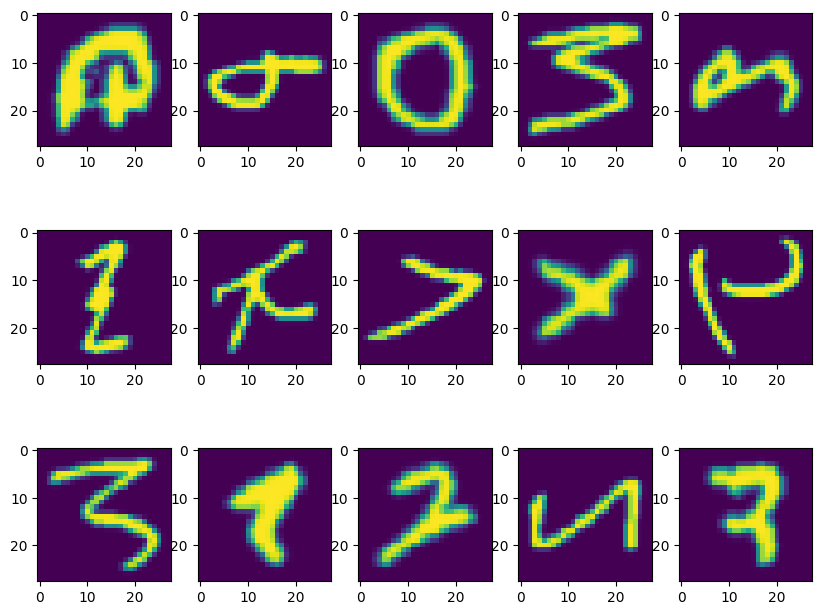

In [6]:
import matplotlib.pyplot as plt 
fig,axes = plt.subplots(3,5,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    ax.imshow(x1[i].reshape([28,28]))

In [7]:
import tensorflow as tf

2026-05-28 16:39:06.561612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779986346.579466    2225 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779986346.585028    2225 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779986346.599609    2225 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986346.599625    2225 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986346.599628    2225 computation_placer.cc:177] computation placer alr

In [8]:
# Normalise and reshape data
train_images = x1 / 255.0
test_images = x2 / 255.0

train_images_number = train_images.shape[0]
train_images_height = 28
train_images_width = 28
train_images_size = train_images_height*train_images_width

train_images = train_images.reshape(train_images_number, train_images_height, train_images_width, 1)

test_images_number = test_images.shape[0]
test_images_height = 28
test_images_width = 28
test_images_size = test_images_height*test_images_width

test_images = test_images.reshape(test_images_number, test_images_height, test_images_width, 1)

In [9]:
# Transform labels
number_of_classes = 37

y1 = tf.keras.utils.to_categorical(y1, number_of_classes)
y2 = tf.keras.utils.to_categorical(y2, number_of_classes)

In [10]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y = train_test_split(train_images,y1,test_size=0.2,random_state = 42, stratify=y1)

In [11]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
 
# ─────────────────────────────────────────
# 1. CUSTOM LAYER — Channel Attention (SE)
# ─────────────────────────────────────────
class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation channel attention."""
 
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
 
    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(max(1, channels // self.reduction_ratio), activation="relu")
        self.fc2 = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))
 
    def call(self, x):
        scale = self.gap(x)
        scale = self.fc1(scale)
        scale = self.fc2(scale)
        scale = self.reshape(scale)
        return x * scale
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction_ratio": self.reduction_ratio})
        return cfg
 
 
# ─────────────────────────────────────────
# 2. CUSTOM LOSS — Label Smoothing CE
# ─────────────────────────────────────────
class LabelSmoothingCrossEntropy(keras.losses.Loss):
    """Cross-entropy with label smoothing to reduce overconfidence."""
 
    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing
 
    def call(self, y_true, y_pred):
        num_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        y_true = tf.cast(y_true, tf.float32)
 
        # One-hot if sparse
        if len(y_true.shape) == 1 or (len(y_true.shape) == 2 and y_true.shape[-1] == 1):
            y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32),
                                tf.cast(num_classes, tf.int32))
 
        smooth_labels = y_true * (1.0 - self.smoothing) + self.smoothing / num_classes
        log_probs = tf.nn.log_softmax(y_pred, axis=-1)
        loss = -tf.reduce_sum(smooth_labels * log_probs, axis=-1)
        return tf.reduce_mean(loss)
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"smoothing": self.smoothing})
        return cfg
 
 
# ─────────────────────────────────────────
# 3. CUSTOM CALLBACK — Verbose Epoch Log
# ─────────────────────────────────────────
class TrainingMonitor(keras.callbacks.Callback):
    """Prints a summary, reduces LR on plateau, and saves BEST FULL MODEL."""
 
    # 1. Ubah default extension dari .h5 ke .keras di sini
    def __init__(self, patience=3, factor=0.5, min_lr=1e-6, filepath="best_model.keras", monitor="val_accuracy"):
        super().__init__()
        self.patience  = patience
        self.factor    = factor
        self.min_lr    = min_lr
        self.filepath  = filepath
        self.monitor   = monitor  
        self._wait     = 0
        self.history   = []
        
        if "acc" in self.monitor:
            self._best = -np.inf  
            self._is_improvement = lambda current, best: current > best  
        else:
            self._best = np.inf   
            self._is_improvement = lambda current, best: current < best  
 
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get("val_loss", float("inf"))
        lr = float(self.model.optimizer.learning_rate)
 
        self.history.append({**logs, "lr": lr, "epoch": epoch + 1})
 
        current_val = logs.get(self.monitor, 0.0 if "acc" in self.monitor else float("inf"))
        
        if self._is_improvement(current_val, self._best):
            self._best = current_val
            self._wait = 0
            
            if self.model is not None:
                # 2. UBAH DI SINI: Gunakan save() bukan save_weights()
                self.model.save(self.filepath)
                print(f"  ★ New best {self.monitor}! Full model saved to {self.filepath}")
        else:
            self._wait += 1
            if self._wait >= self.patience:
                new_lr = max(lr * self.factor, self.min_lr)
                self.model.optimizer.learning_rate = new_lr
                print(f"  ↓ LR reduced → {new_lr:.2e}")
                self._wait = 0
 
    # def on_train_end(self, logs=None):
    #     print(f"\n  Training complete. Best {self.monitor}: {self._best:.4f}")
 
 
# ─────────────────────────────────────────
# 4. MISH ACTIVATION
# ─────────────────────────────────────────
def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))
 
 
# ─────────────────────────────────────────
# 5. CNN BLOCK BUILDER
# ─────────────────────────────────────────
def cnn_block(x, filters, activation_fn, block_id=0):
    """Conv → BN → Act → Conv → BN → Act → Pool → Dropout → Attention."""
    x = layers.Conv2D(filters, 3, padding="same", name=f"b{block_id}_conv1")(x)
    x = layers.BatchNormalization(name=f"b{block_id}_bn1")(x)
    x = layers.Activation(activation_fn, name=f"b{block_id}_act1")(x)
 
    x = layers.Conv2D(filters, 3, padding="same", name=f"b{block_id}_conv2")(x)
    x = layers.BatchNormalization(name=f"b{block_id}_bn2")(x)
    x = layers.Activation(activation_fn, name=f"b{block_id}_act2")(x)
 
    x = layers.MaxPooling2D(2, name=f"b{block_id}_pool")(x)
    x = layers.Dropout(0.25, name=f"b{block_id}_drop")(x)
    x = ChannelAttention(name=f"b{block_id}_attn")(x)
 
    return x
 
 
# ─────────────────────────────────────────
# 6. FULL MODEL — Functional API
# ─────────────────────────────────────────
def build_emnist_model(num_classes=37, input_shape=(28, 28, 1)):
    """
    5 CNN blocks — alternating Mish / ReLU:
      Block 1: Mish  | Block 2: ReLU  | Block 3: Mish
      Block 4: ReLU  | Block 5: Mish
    """
    cfg = [
        (32,  mish),
        (64,  keras.activations.get('relu')),
        (128, mish),
        (256, keras.activations.get('relu')),
        # (256, mish),
    ]
 
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs
 
    for i, (filters, act) in enumerate(cfg, start=1):
        x = cnn_block(x, filters, act, block_id=i)
 
    # Classifier head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(512, name="fc1")(x)
    x = layers.Activation(mish, name="fc1_act")(x)
    x = layers.Dropout(0.5, name="fc1_drop")(x)
    x = layers.Dense(256, activation="relu", name="fc2")(x)
    x = layers.Dropout(0.3, name="fc2_drop")(x)
    outputs = layers.Dense(num_classes, name="logits")(x)   # raw logits
 
    return keras.Model(inputs, outputs, name="EMNIST_CNN")
 
 
# ─────────────────────────────────────────
# 7. COMPILE HELPER
# ─────────────────────────────────────────
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=LabelSmoothingCrossEntropy(smoothing=0.1),
        metrics=["accuracy"],
    )
    return model
 
 
# ─────────────────────────────────────────
# 8. HISTORY PLOT
# ─────────────────────────────────────────
def plot_history(history):
    """
    Pass the Keras History object returned by model.fit().
    Saves 'training_history.png' and displays the plot.
    """
    h = history.history if hasattr(history, "history") else history
 
    epochs  = range(1, len(h["loss"]) + 1)
    TRAIN_C = "#00e5ff"
    VAL_C   = "#ff4081"
    GRID_C  = "#2a2a2a"
    TEXT_C  = "#e0e0e0"
 
    fig = plt.figure(figsize=(14, 5), facecolor="#0f0f0f")
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
 
    def styled_ax(pos, title, ylabel):
        ax = fig.add_subplot(pos)
        ax.set_facecolor("#1a1a1a")
        ax.set_title(title, color=TEXT_C, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("Epoch", color=TEXT_C, fontsize=10)
        ax.set_ylabel(ylabel, color=TEXT_C, fontsize=10)
        ax.tick_params(colors=TEXT_C)
        ax.grid(True, color=GRID_C, linewidth=0.8, linestyle="--")
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_C)
        return ax
 
    ax1 = styled_ax(gs[0], "Loss", "Loss")
    ax1.plot(epochs, h["loss"],     color=TRAIN_C, lw=2, label="Train")
    ax1.plot(epochs, h["val_loss"], color=VAL_C,   lw=2, label="Val", linestyle="--")
    ax1.legend(facecolor="#2a2a2a", edgecolor=GRID_C, labelcolor=TEXT_C)
 
    ax2 = styled_ax(gs[1], "Accuracy", "Accuracy")
    ax2.plot(epochs, h["accuracy"],     color=TRAIN_C, lw=2, label="Train")
    ax2.plot(epochs, h["val_accuracy"], color=VAL_C,   lw=2, label="Val", linestyle="--")
    ax2.legend(facecolor="#2a2a2a", edgecolor=GRID_C, labelcolor=TEXT_C)
 
    fig.suptitle("EMNIST CNN — Training History", color=TEXT_C,
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    # plt.savefig("training_history.png", dpi=150, bbox_inches="tight",
    #             facecolor=fig.get_facecolor())
    plt.show()
    # print("Saved → training_history.png")

In [18]:
model   = build_emnist_model(num_classes=number_of_classes)
model   = compile_model(model, learning_rate=1e-3)
model.summary()

Model: "EMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_act1 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_act2 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_drop (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_attn (ChannelAttention)      │ (None, 14, 14, 32)     │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_act1 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_act2 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_drop (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_attn (ChannelAttention)      │ (None, 7, 7, 64)       │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_act1 (Activation)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_act2 (Activation)            │ (None, 7, 7, 128)      │             

 Total params: 1,470,241 (5.61 MB)

 Trainable params: 1,468,321 (5.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5605 - loss: 1.9437  ★ New best val_accuracy! Full model saved to best_model.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.5609 - loss: 1.9427 - val_accuracy: 0.9154 - val_loss: 0.9058
Epoch 2/30
552/555 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9147 - loss: 0.9543  ★ New best val_accuracy! Full model saved to best_model.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9147 - loss: 0.9542 - val_accuracy: 0.9363 - val_loss: 0.8452
Epoch 3/30
553/555 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9292 - loss: 0.8918  ★ New best val_accuracy! Full model saved to best_model.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9292 - loss: 0.8918 - val_accuracy: 0.9376 - val_loss: 0.8309
Epoch 4/30
553/555 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9374 - loss: 0.8656  ★ New best val_accuracy! Full model saved to best_model.keras
555/555 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - a

/tmp/ipykernel_57/2105864893.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


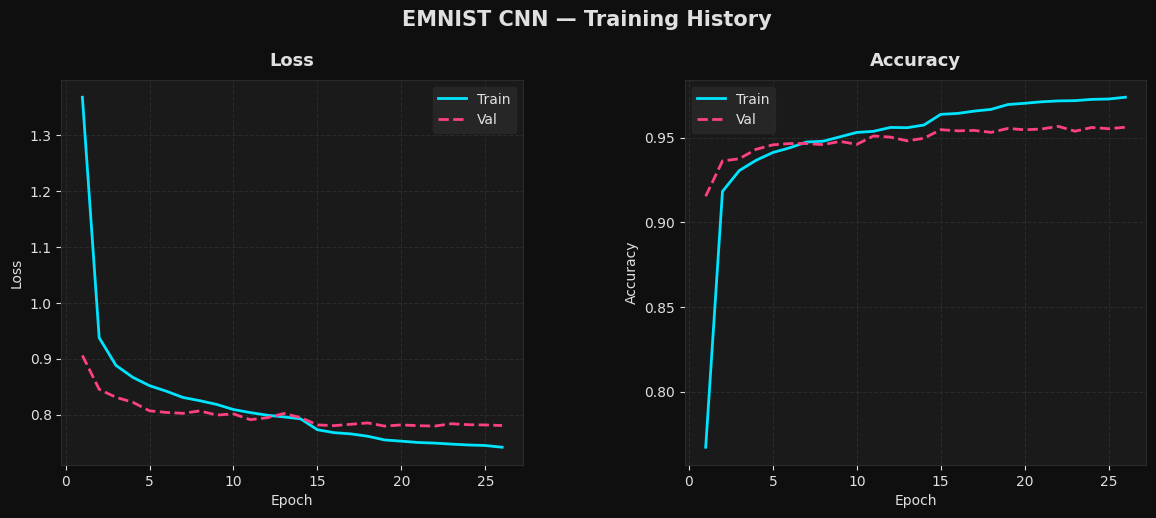

In [19]:
import os

# 1. Tentukan folder tempat menyimpan log TensorBoard
log_dir = os.path.join("logs", "emnist_cnn")

# 2. Inisialisasi TensorBoard Callback bawaan Keras
tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,      # Mencatat distribusi bobot (weights) setiap epoch
    write_graph=True,      # Menyimpan grafik arsitektur model
    update_freq="epoch"    # Menulis log setiap akhir epoch (bisa diganti 'batch')
)

monitor = TrainingMonitor(patience=3, factor=0.5, filepath="best_model.keras")

history = model.fit(
    train_x, train_y,
    validation_data=(test_x, test_y),
    epochs=30,
    batch_size=128,
    verbose=1,
    callbacks=[monitor,
               keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
              tensorboard_callback],
)

plot_history(history)

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report

# ────────────────────────────────────────────────────────
# 1. LOAD MODEL PENUH SECARA LANGSUNG
# ────────────────────────────────────────────────────────
# Masukkan semua kelas/fungsi kustom Anda ke dalam custom_objects
print("★ Memuat model penuh dari file .keras...")
model = keras.models.load_model(
    "/kaggle/working/best_model.keras",
    custom_objects={
        "ChannelAttention": ChannelAttention,
        "LabelSmoothingCrossEntropy": LabelSmoothingCrossEntropy,
        "mish": mish
    }
)
print("★ Model berhasil dimuat sepenuhnya tanpa perlu rebuild arsitektur!")


# ── Inference ──────────────────────────────────────────
# Catatan: Karena model Anda mengembalikan 'logits' (belum dilewatkan ke Softmax),
# penggunaan np.argmax di sini sudah benar untuk mengambil indeks kelas tertinggi.
logits = model.predict(test_x, batch_size=128)
preds  = np.argmax(logits, axis=-1)
labels = np.argmax(test_y, axis=-1) if test_y.ndim == 2 else test_y.ravel().astype(int)


# ── Classification Report ───────────────────────────────
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(labels, preds))

★ Memuat model penuh dari file .keras...


I0000 00:00:1779986373.885184    2225 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


★ Model berhasil dimuat sepenuhnya tanpa perlu rebuild arsitektur!


I0000 00:00:1779986375.960347    2266 service.cc:152] XLA service 0x7ba64c012150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779986375.960379    2266 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779986376.139463    2266 cuda_dnn.cc:529] Loaded cuDNN version 91002


 42/139 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

I0000 00:00:1779986377.779066    2266 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       0.96      0.97      0.97       679
           2       0.99      0.99      0.99       679
           3       0.99      0.98      0.98       684
           4       0.98      0.98      0.98       680
           5       0.99      0.98      0.98       687
           6       0.97      0.99      0.98       679
           7       0.95      0.88      0.91       677
           8       0.97      0.98      0.97       685
           9       0.77      0.76      0.77       686
          10       0.97      0.96      0.96       680
          11       0.99      0.99      0.99       688
          12       0.77      0.77      0.77       683
          13       0.99      0.99      0.99       680
          14       0.99      0.97      0.98       673
          15       0.98      0.98      0.98       682
          16       0.99      0.98      0.99       686
        

In [13]:
!pip install fastapi uvicorn pyngrok nest-asyncio

In [20]:
import os
from pyngrok import ngrok

# 1. Masukkan authtoken ngrok Anda di sini
NGROK_TOKEN = "3EMLXdLXO3ZrMHsVwlnHYHG7sjA_2V4KB9CQjMnEcfjCbKn9g"
ngrok.set_auth_token(NGROK_TOKEN)

# 2. Buat folder log jika belum ada (sesuaikan dengan callback training Anda)
LOG_DIR = "./logs"
os.makedirs(LOG_DIR, exist_ok=True)

# 3. Jalankan TensorBoard di latar belakang (background process)
get_ipython().system_raw(f"tensorboard --logdir {LOG_DIR} --host 0.0.0.0 --port 6006 &")

# 4. Buka tunnel publik untuk TensorBoard
tb_tunnel = ngrok.connect(6006, "http")
print(f"★ TensorBoard URL: {tb_tunnel.public_url}")

★ TensorBoard URL: https://abnormal-overbid-cycling.ngrok-free.dev


2026-05-28 16:43:00.621073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779986580.644619    2495 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779986580.652681    2495 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779986580.671159    2495 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986580.671186    2495 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986580.671188    2495 computation_placer.cc:177] computation placer alr

In [6]:
import asyncio
import nest_asyncio
import uvicorn
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pyngrok import ngrok

# 1. Izinkan bersarangnya event loop di Jupyter Notebook
nest_asyncio.apply()

app = FastAPI(title="EMNIST Inference & TensorBoard API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.get("/")
def read_root():
    return {"message": "FastAPI di Kaggle berhasil berjalan!", "status": "healthy"}

@app.get("/api/status")
def get_status():
    return {"tensorboard_connected": True, "log_directory": "./logs"}

# 2. Nyalakan Ngrok Tunnel (Port 8000)
try:
    api_tunnel = ngrok.connect(8000, "http")
    print(f"★ FastAPI URL Public: {api_tunnel.public_url}")
    print(f"★ Swagger UI Docs: {api_tunnel.public_url}/docs")
except Exception as e:
    print(f"Ngrok error atau tunnel sudah terbuka: {e}")

# ────────────────────────────────────────────────────────
# 3. SOLUSI FIX RUNTIME ERROR (Python 3.12+ Jupyter)
# ────────────────────────────────────────────────────────
# Kita buat konfigurasi Uvicorn secara manual
config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)

# Ambil event loop Jupyter yang sedang berjalan, lalu daftarkan server ke dalamnya
loop = asyncio.get_event_loop()
loop.create_task(server.serve())

★ FastAPI URL Public: https://abnormal-overbid-cycling.ngrok-free.dev
★ Swagger UI Docs: https://abnormal-overbid-cycling.ngrok-free.dev/docs


<Task pending name='Task-8' coro=<Server.serve() running at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77>>

INFO:     Started server process [2557]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): [errno 98] address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
t=2026-05-28T16:46:46+0000 lvl=warn msg="Stopping forwarder" name=http-8000-9509939c-a917-457f-a640-c322a244892d acceptErr="failed to accept connection: Listener closed"


In [5]:
ngrok.kill()

In [16]:
import os
import asyncio
import nest_asyncio
import uvicorn
from fastapi import FastAPI, Security, HTTPException, status
from fastapi.security.api_key import APIKeyHeader
from fastapi.middleware.cors import CORSMiddleware
from pyngrok import ngrok

nest_asyncio.apply()

app = FastAPI(title="EMNIST Protected API")

# 1. Tentukan nama Header yang akan dibaca (misal: X-API-Key)
API_KEY_NAME = "X-API-Key"
api_key_header = APIKeyHeader(name=API_KEY_NAME, auto_error=False)

# 2. Definisikan API Key Anda (Sangat disarankan menggunakan Environment Variable)
# Di Kaggle, Anda bisa mengaturnya lewat menu: Add-ons -> Secrets
API_KEY = os.environ.get("MY_SECRET_API_KEY", "Model69CHAR67DIcoding")

# 3. Fungsi Validator untuk mengecek kecocokan kunci
async def get_api_key(api_key_header: str = Security(api_key_header)):
    if api_key_header == API_KEY:
        return api_key_header
    raise HTTPException(
        status_code=status.HTTP_403_FORBIDDEN,
        detail="API Key tidak valid atau tidak disertakan!"
    )

# CORS Setup
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# 4. Contoh Endpoint Terproteksi (Tambahkan: dependencies=[Security(get_api_key)])
@app.get("/api/predict", dependencies=[Security(get_api_key)])
def get_prediction():
    return {"status": "success", "prediction": "Hasil inferensi model EMNIST"}

# Endpoint Publik (Tanpa proteksi, misalnya untuk pengecekan web server)
@app.get("/")
def read_root():
    return {"message": "Server aktif"}

# Jalankan Uvicorn Server seperti sebelumnya
config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)
loop = asyncio.get_event_loop()
loop.create_task(server.serve())

<Task pending name='Task-1' coro=<Server.serve() running at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77>>

INFO:     Started server process [2225]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
